In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
x_train = np.array([[1,1], [1,2], [2,1], [3,2], [3,3], [4,3], [4,5,], [5,6], [6,6]])
y_train = np.array([0,0,0,0,0,1,1,1,1]).ravel()

In [ ]:
print(x_train.shape)
print(y_train.shape)

(9, 2)
(9,)


In [ ]:
def compute_gradient(x_train, y_train, w, b):
  m, n = x_train.shape
  dj_dw = np.zeros(n)
  dj_db = 0

  for i in range(m):
    pred = x_train[i] @ w + b
    sig = 1/(1+np.exp(-pred))
    error = sig - y_train[i]
    dj_dw += error*x_train[i]
    dj_db += error

  dj_dw /= m
  dj_db /= m

  return dj_dw, dj_db


In [ ]:
def run_gradient(x_trian, y_train, alpha, epochs):
  m,n = x_train.shape
  w = np.zeros(n)
  b = 0

  for i in range(epochs):
    dw, db = compute_gradient(x_train, y_train, w, b)

    w = w - alpha*dw
    b = b - alpha*db

    if i % 1000 == 0 : print(f"weight:{w}, bias:{b}")

  return w, b

In [ ]:
w, b = run_gradient(x_train, y_train, 0.1, 10000)

weight:[0.05       0.06111111], bias:-0.005555555555555556
weight:[0.82747034 0.90419041], bias:-5.582064699324508
weight:[1.42164294 0.86512071], bias:-7.533708711002967
weight:[1.86767319 0.81902198], bias:-8.952140726503654
weight:[2.23237141 0.78285186], bias:-10.118010517584493
weight:[2.54283173 0.75569955], bias:-11.122085918697254
weight:[2.81381955 0.73514787], bias:-12.008291814482948
weight:[3.05452859 0.71928028], bias:-12.802831884736278
weight:[3.27115628 0.70676567], bias:-13.523292017388469
weight:[3.46811579 0.69669778], bias:-14.182339634342716


In [ ]:
def predict(x_train, w, b):
  m = x_train.shape[0]
  y_pred = np.zeros(m)
  print(y_pred.shape)

  for i in range(m):
    pred = x_train[i]@w+b
    sig = 1/(1+np.exp(-pred))
    y_pred[i] = sig
  return y_pred

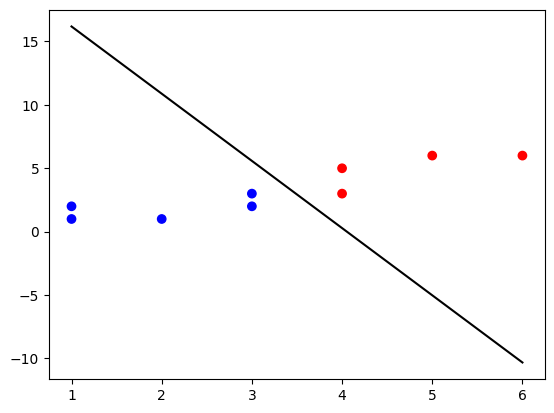

In [ ]:
plt.scatter(
    x_train[:,0],
    x_train[:,1],
    c=y_train,
    cmap="bwr"
)

x1 = np.linspace(
    x_train[:,0].min(),
    x_train[:,0].max(),
    100
)

x2 = -(w[0]*x1 + b)/w[1]

plt.plot(x1, x2, 'k-')
plt.show()

In [ ]:
pred_prob = predict(x_train, w, b)
pred_class = (pred_prob >= 0.5).astype(int)

accuracy = np.mean(pred_class == y_train)
print("Accuracy:", accuracy)

(9,)
Accuracy: 1.0


In [ ]:
pred_class == y_train

array([ True,  True,  True,  True,  True,  True,  True,  True,  True])